# Paired vs published ttbar event audit

Compare independent events, not event-by-event identical truth. Every comparable feature uses blue for the new paired sample and orange for the published release on the same axes. Histograms use shared bins and density normalization.


In [1]:
from pathlib import Path

SAMPLE = 'pu0'  # 'pu0' or 'pu200'
NEW_EVENT = 0
PUBLISHED_EVENT = 0
NEW_ROOT = Path('/tmp/colliderml-paired-40167/output/paired-samples-features-n1')
PUBLISHED_ROOT = Path('/mnt/data2/data/collider_ml/CERN__ColliderML-Release-1')
SCATTER_LIMIT = 10000


In [2]:
import sys
from IPython.display import display

module_dirs = (Path.cwd(), Path.cwd() / 'notebooks' / 'validation', Path.cwd().parent / 'validation')
module_dir = next((path for path in module_dirs if (path / 'paired_vs_published.py').is_file()), None)
if module_dir is None:
    raise FileNotFoundError('Run Jupyter from the repo root or notebooks/validation directory')
sys.path.insert(0, str(module_dir))
from paired_vs_published import (load_event, validate_event, feature_coverage, missingness,
                                 plot_particles, plot_hits, plot_cells, plot_missingness)

data = load_event(NEW_ROOT, PUBLISHED_ROOT, SAMPLE, NEW_EVENT, PUBLISHED_EVENT)
print(f'{SAMPLE}: new event {NEW_EVENT}, published event {PUBLISHED_EVENT}')
print('New files:', *(str(path) for path in data.new_paths.values()), sep='\n  ')
print('Published files:', *(str(path) for path in data.public_paths.values()), sep='\n  ')


pu0: new event 0, published event 0
New files:
  /tmp/colliderml-paired-40167/output/paired-samples-features-n1/pu0/particles.parquet
  /tmp/colliderml-paired-40167/output/paired-samples-features-n1/pu0/hits.parquet
  /tmp/colliderml-paired-40167/output/paired-samples-features-n1/pu0/cells.parquet
Published files:
  /mnt/data2/data/collider_ml/CERN__ColliderML-Release-1/ttbar_pu0_particles/data/ttbar_pu0_particles/train-00000-of-01000.parquet
  /mnt/data2/data/collider_ml/CERN__ColliderML-Release-1/ttbar_pu0_tracker_hits/data/ttbar_pu0_tracker_hits/train-00000-of-01000.parquet


## Integrity and feature coverage
Every input column appears in the coverage table. Identifier columns are checked or summarized rather than histogrammed.


In [3]:
display(validate_event(data))
display(feature_coverage(data))
display(missingness(data))
for kind, schema in data.new_schemas.items():
    print(f'New {kind}: {schema}')
for kind, schema in data.public_schemas.items():
    print(f'Published {kind}: {schema}')


,Metric,New,Published
0,Events in report,2,NaN
1,Particles,2034,1846.0
2,Hits,1583,1636.0
3,Cells,8030,NaN
4,Orphan cells,0,NaN
5,Wrong cell geometry,0,NaN
6,Unmatched hit labels,0,NaN
7,Unmatched contributor IDs,0,NaN
8,Null scalar hit labels,27,0.0
9,Multi-SimHit measurements,32,NaN


,Table,Feature,New column,Published column,Treatment
0,particles,charge,charge,charge,overlay
1,particles,energy,energy,energy,overlay
2,particles,event_id,event_id,event_id,ID/integrity
3,particles,mass,mass,mass,overlay
4,particles,num_calo_hits,num_calo_hits,,new only
5,particles,num_tracker_hits,num_tracker_hits,,new only
6,particles,parent_id,parent_id,parent_id,ID/integrity
7,particles,particle_id,particle_id,particle_id,ID/integrity
8,particles,pdg_id,pdg_id,pdg_id,overlay
9,particles,perigee_d0,perigee_d0,perigee_d0,overlay


,Table,Feature,Source,Count,Missing,Missing fraction
0,particles,pdg_id,New,2034,0,0.000000
1,particles,pdg_id,Published,1846,0,0.000000
2,particles,mass,New,2034,0,0.000000
3,particles,mass,Published,1846,0,0.000000
4,particles,energy,New,2034,0,0.000000
5,particles,energy,Published,1846,0,0.000000
6,particles,charge,New,2034,0,0.000000
7,particles,charge,Published,1846,0,0.000000
8,particles,vx,New,2034,0,0.000000
9,particles,vx,Published,1846,0,0.000000


New particles: event_id: uint32
particle_id: list<element: uint64>
  child 0, element: uint64
pdg_id: list<element: int64>
  child 0, element: int64
mass: list<element: float>
  child 0, element: float
energy: list<element: float>
  child 0, element: float
charge: list<element: float>
  child 0, element: float
vx: list<element: float>
  child 0, element: float
vy: list<element: float>
  child 0, element: float
vz: list<element: float>
  child 0, element: float
time: list<element: float>
  child 0, element: float
px: list<element: float>
  child 0, element: float
py: list<element: float>
  child 0, element: float
pz: list<element: float>
  child 0, element: float
num_tracker_hits: list<element: uint16>
  child 0, element: uint16
num_calo_hits: list<element: uint16>
  child 0, element: uint16
primary: list<element: bool>
  child 0, element: bool
vertex_primary: list<element: uint16>
  child 0, element: uint16
parent_id: list<element: int64>
  child 0, element: int64
perigee_d0: list<elem

## Particle features
Shared values are overlaid. Hit-count fields exist only in the new file.


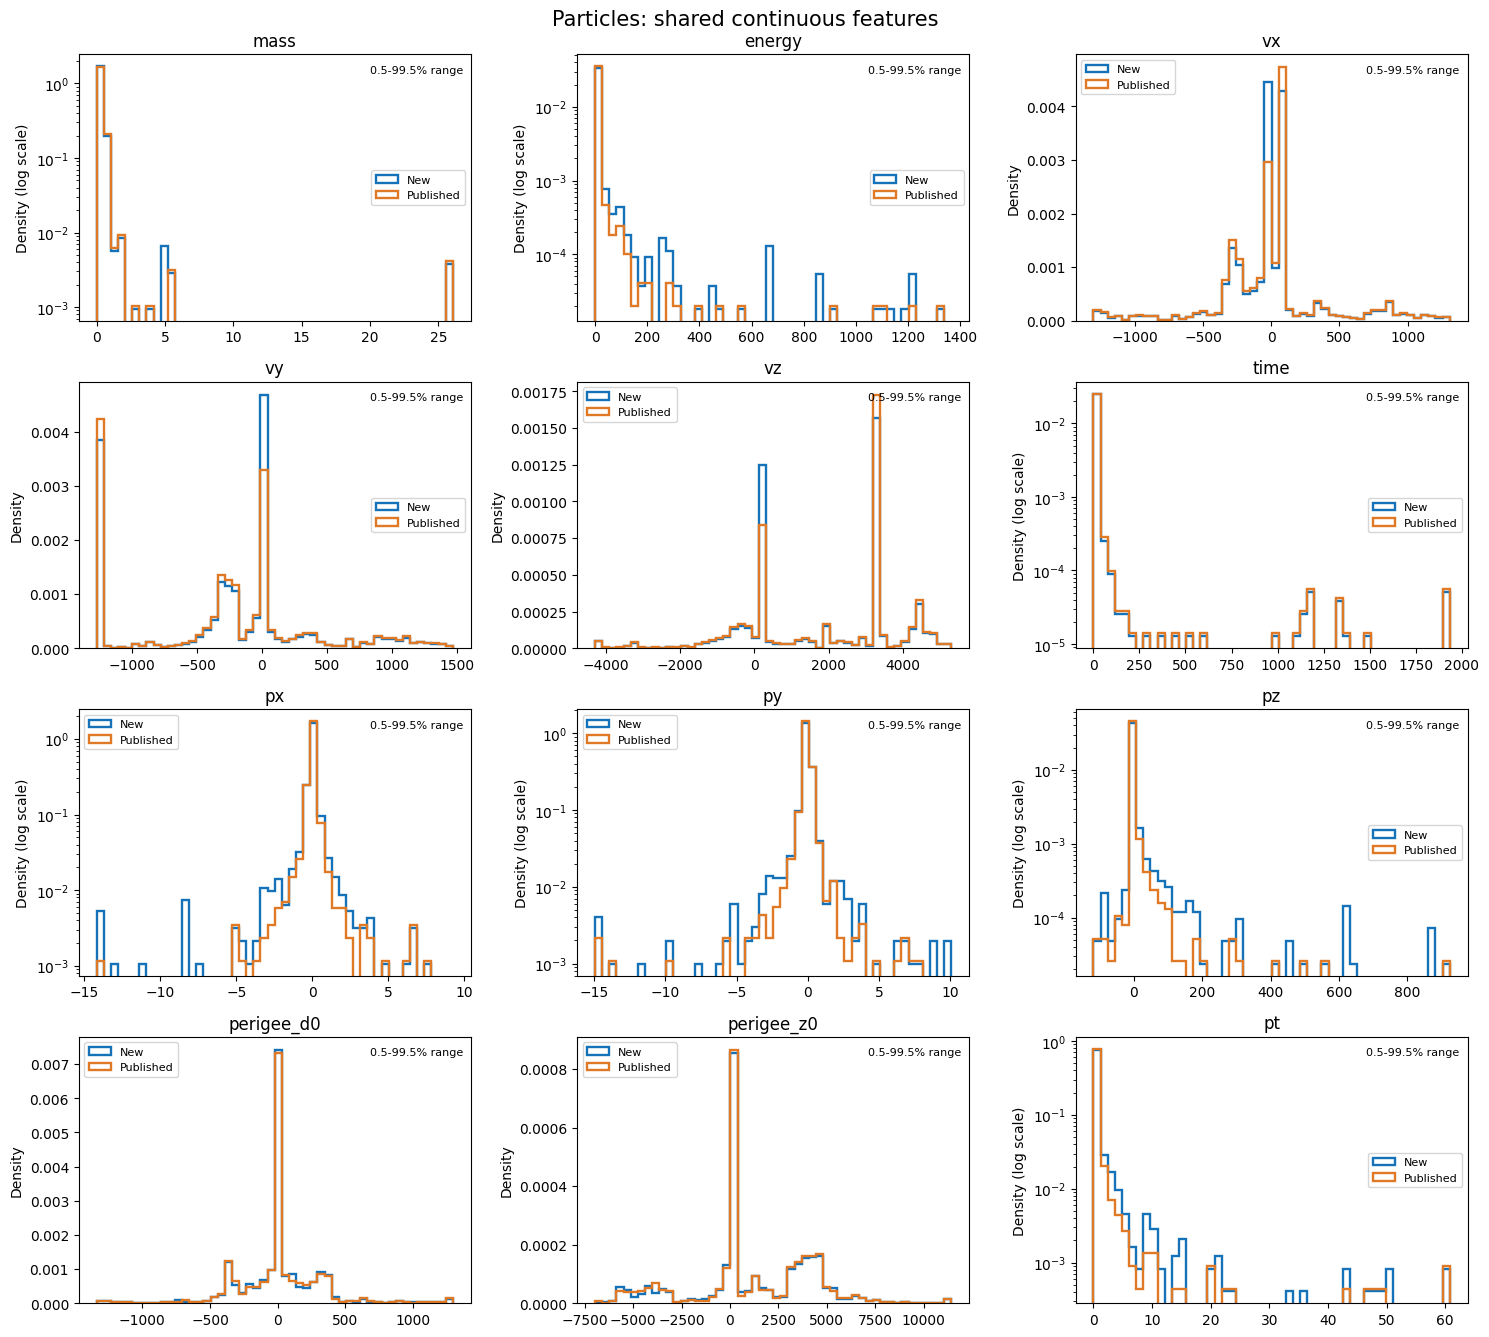

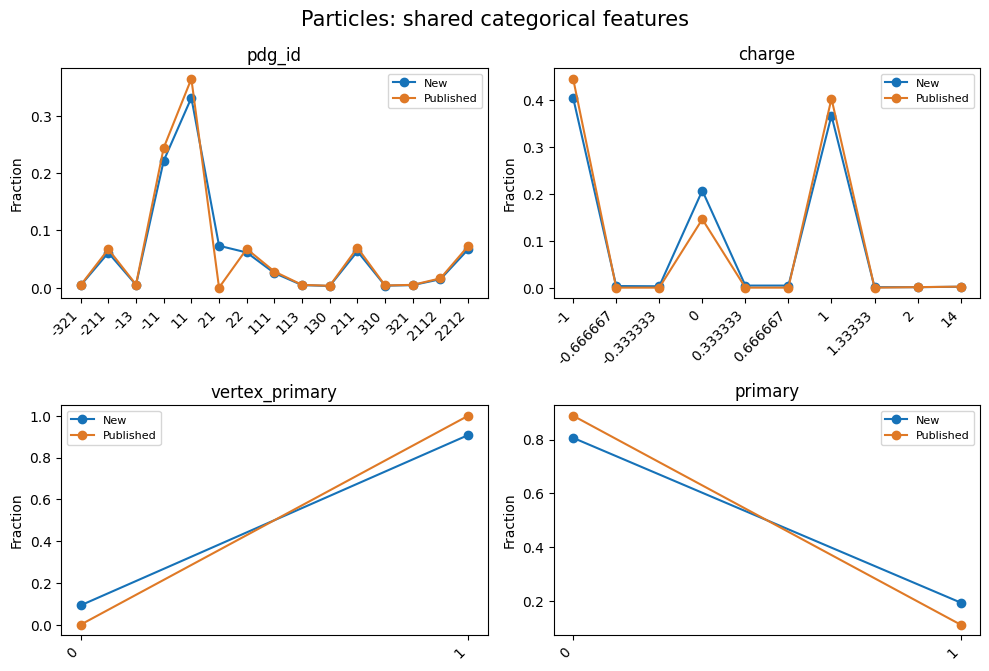

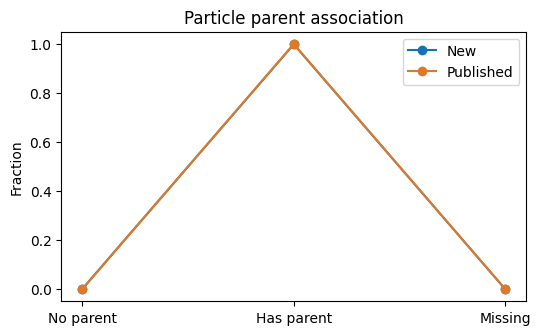

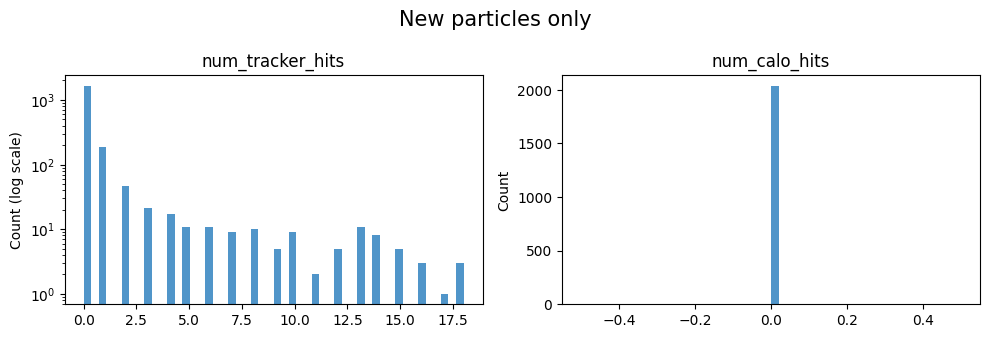

In [4]:
plot_particles(data)


## Hit features
The reconstructed positions and decoded geometry are comparable. Truth coordinates, time, and detector are published-only; cell-local coordinates and contributor counts are new-only.


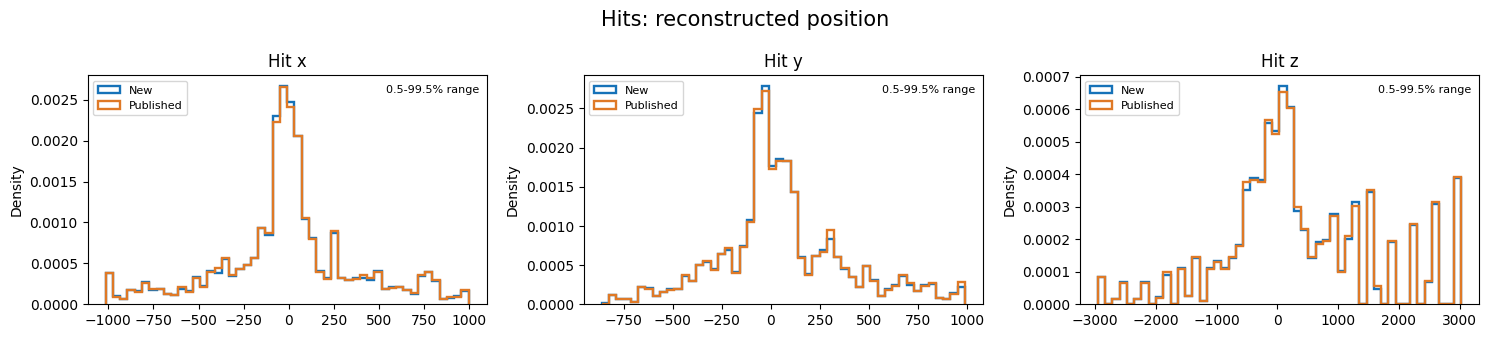

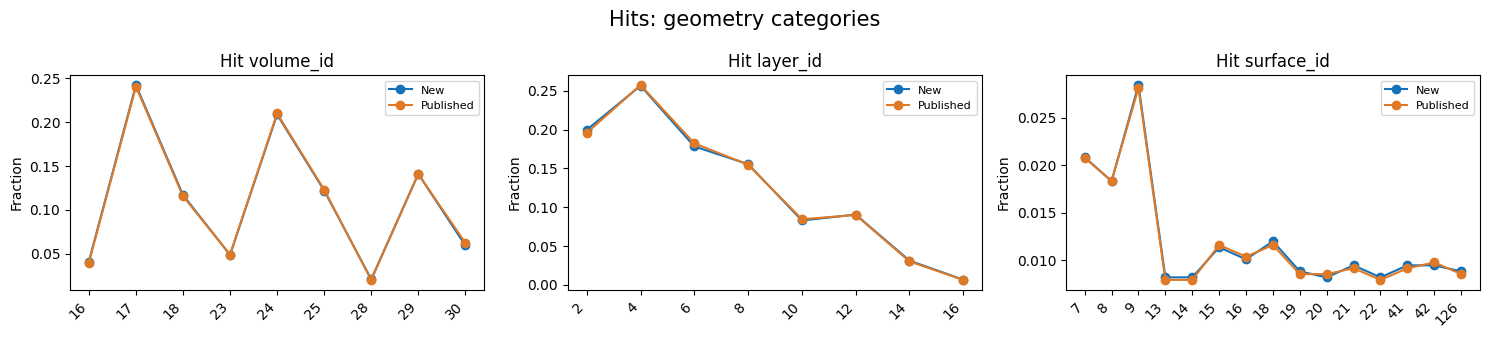

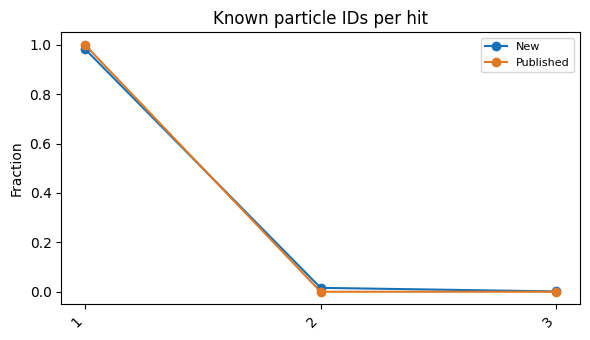

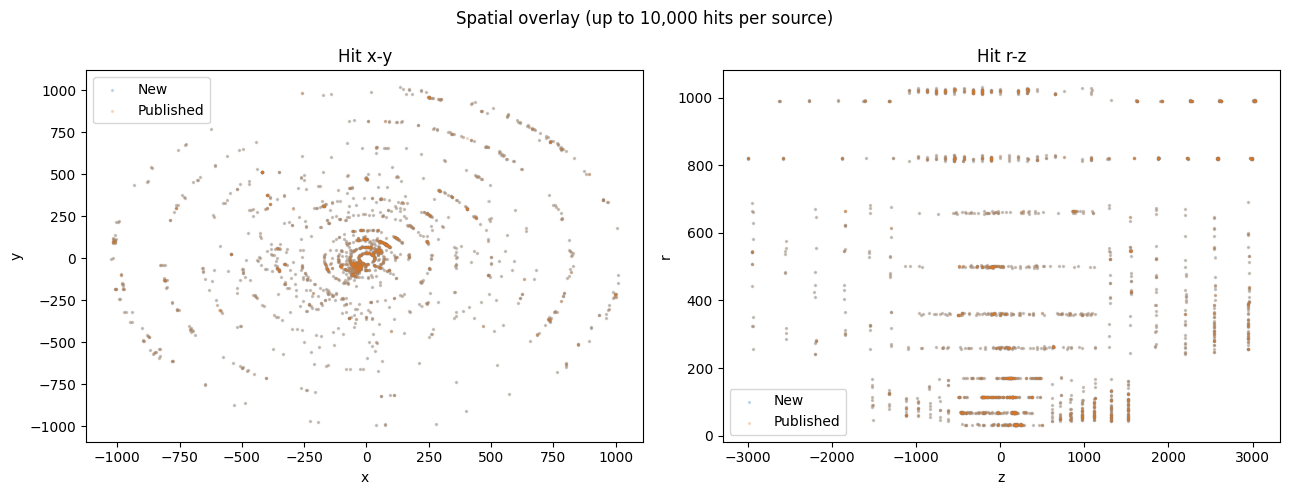

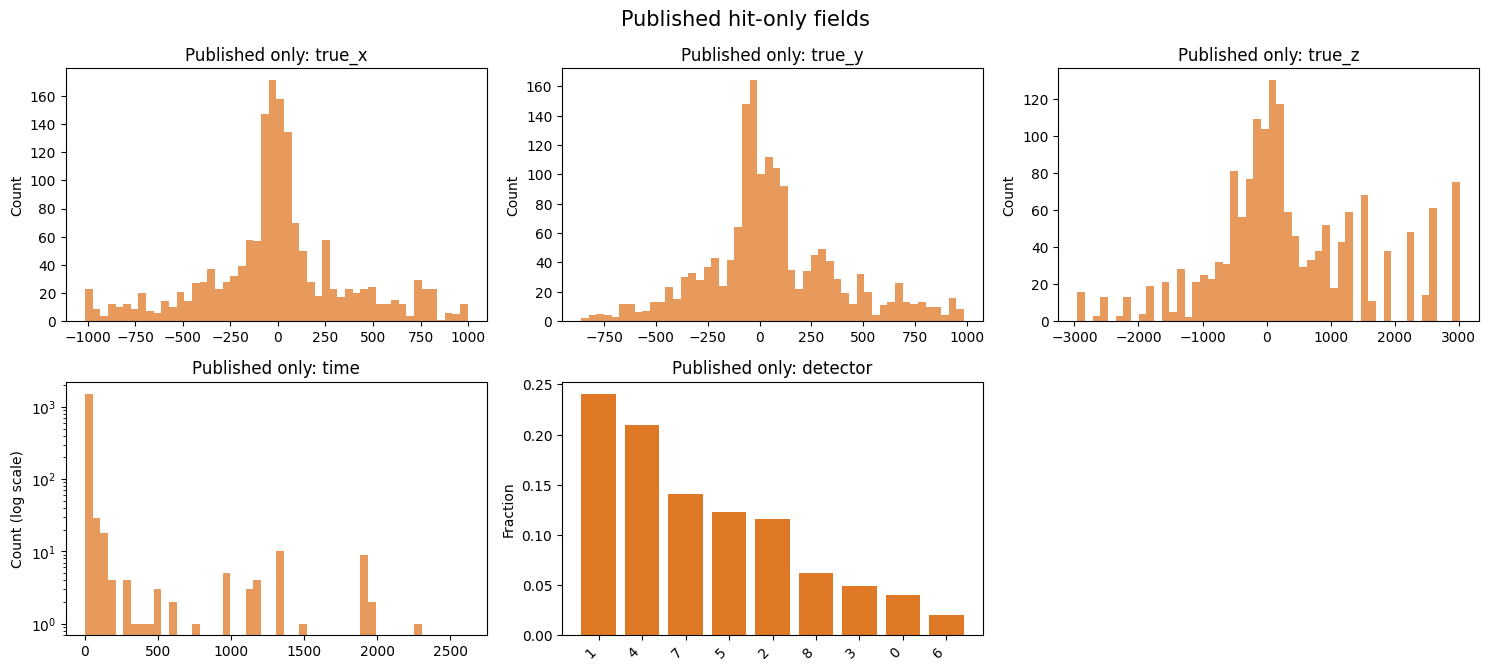

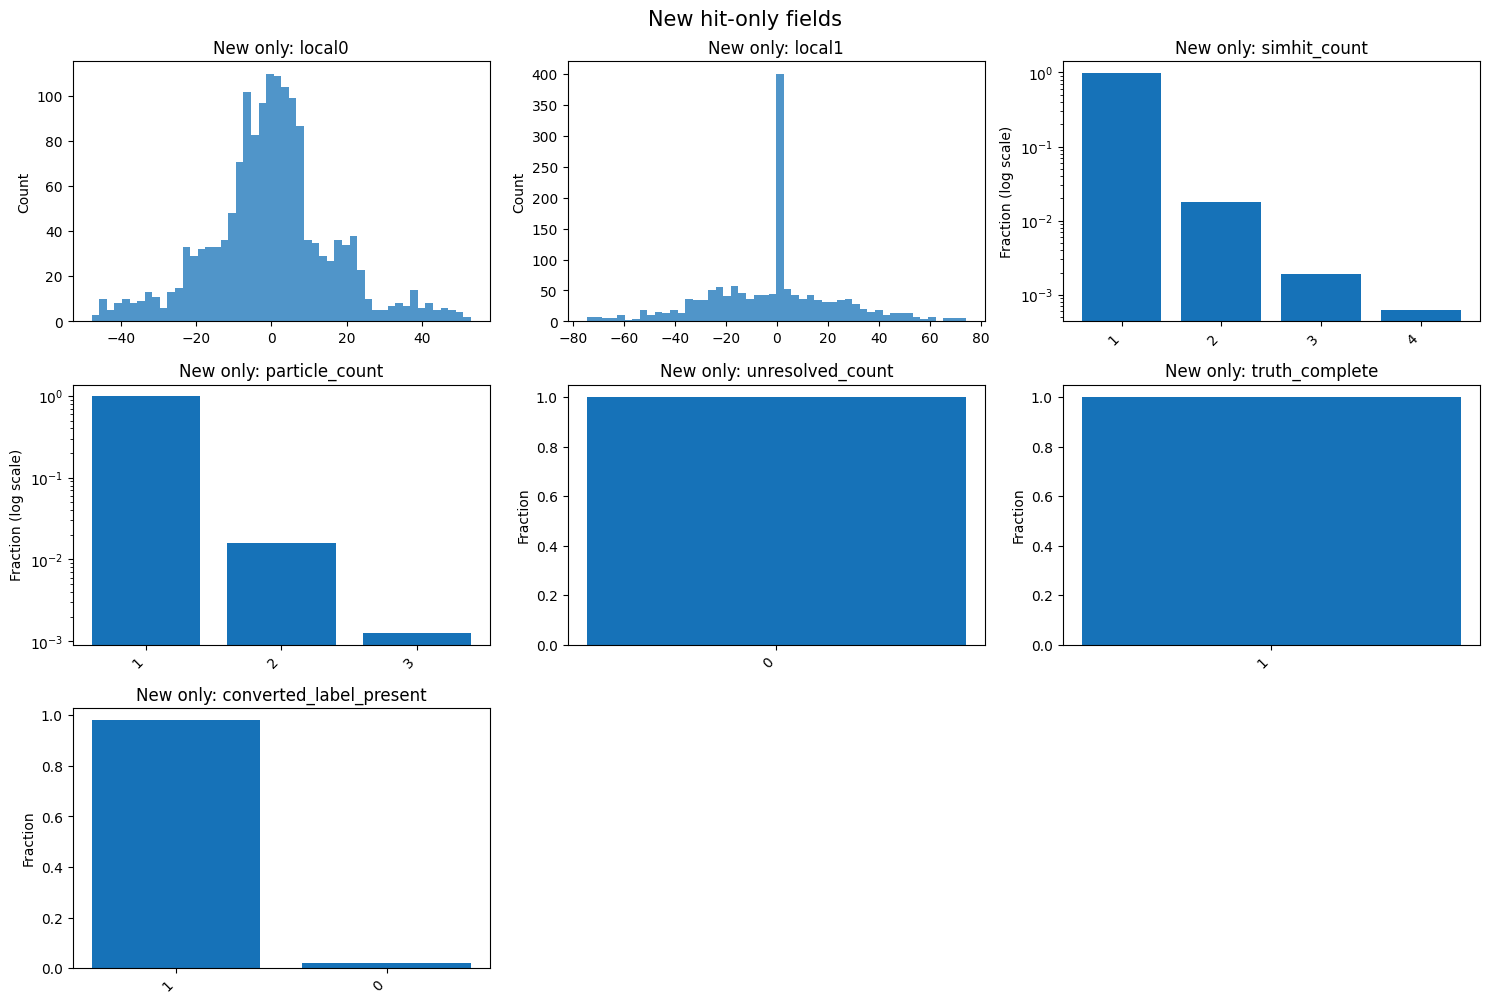

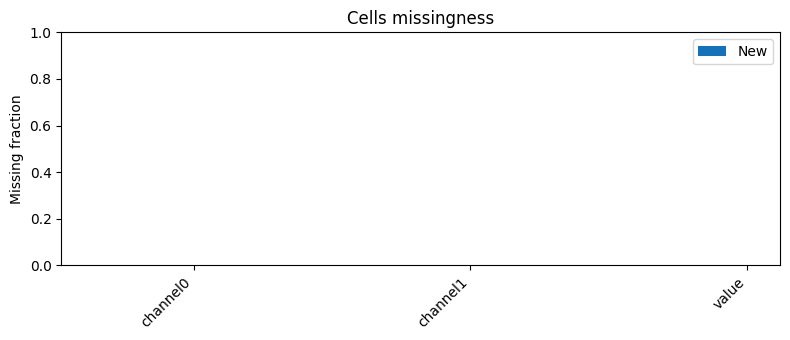

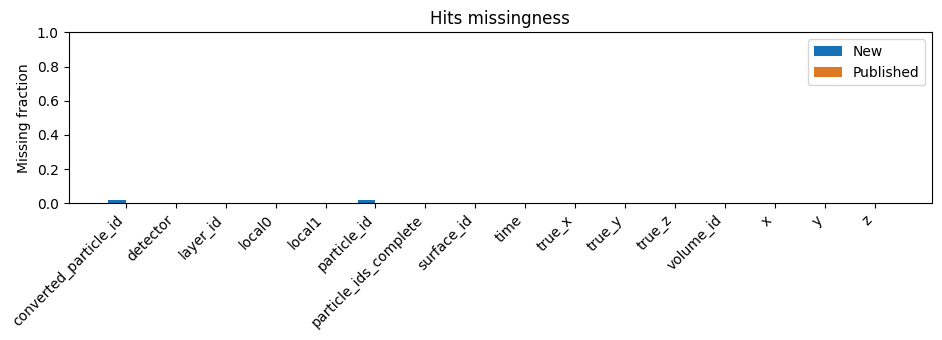

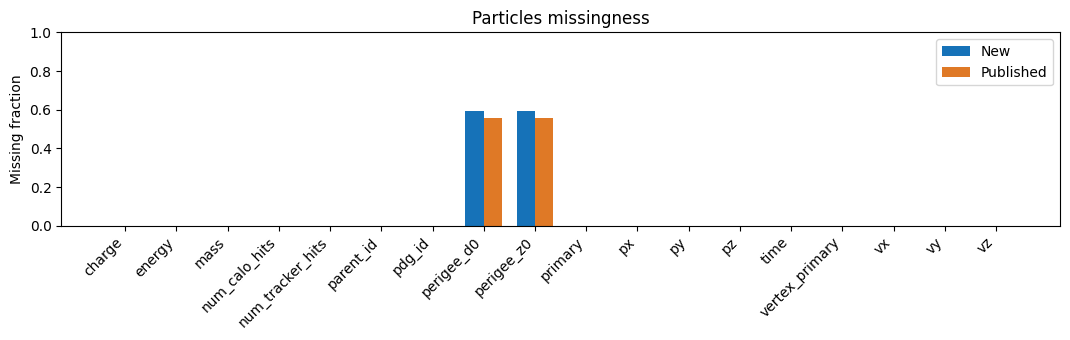

In [5]:
plot_hits(data, scatter_limit=SCATTER_LIMIT)
plot_missingness(data)


## Constituent cells
The published release has no cell table, so these plots show only the new sample.


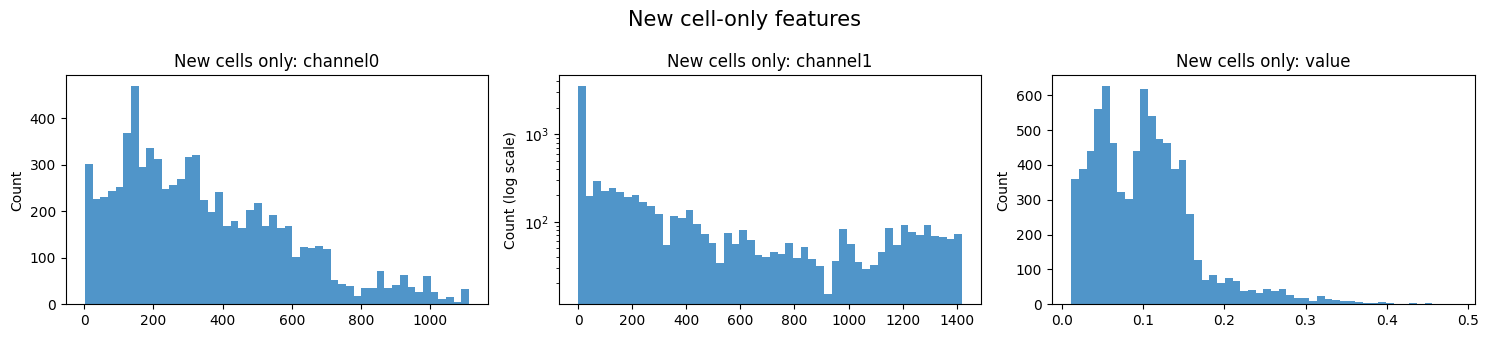

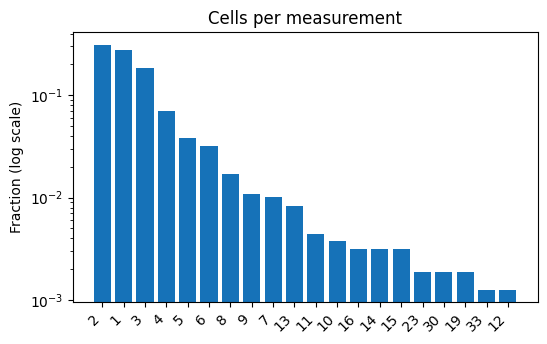

In [6]:
plot_cells(data)
